# Decision Tree

In [6]:
import seaborn as sns

data = sns.load_dataset("titanic")
data.head(2)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False


In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [9]:
prep_data = data.drop(columns=["alive","who", "adult_male", "class", "embark_town"])
prep_data.drop("deck", axis=1, inplace=True)
prep_data.head(2)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.0,1,0,7.2500,S,False
1,1,1,female,38.0,1,0,71.2833,C,False


In [13]:
import pandas as pd
import numpy as np

df = pd.DataFrame(np.random.randn(5,4), columns=["C1","C2","C3","C4"])
df.loc[[0,1],'C1'] = None
df.loc[2,'C2'] = np.nan
df.loc[2,'C3'] = np.nan
df

,C1,C2,C3,C4
0,NaN,0.013176,1.243190,-0.740061
1,NaN,-0.497630,0.217923,-0.923424
2,1.239133,NaN,NaN,0.465781
3,1.248878,-0.616657,1.068583,-0.308896
4,0.603976,0.739612,-0.282273,0.037589


In [16]:
df_dop_row = df.dropna(axis = 0) # NaN이 있는 행 모두 삭제
df_dop_row

,C1,C2,C3,C4
3,1.248878,-0.616657,1.068583,-0.308896
4,0.603976,0.739612,-0.282273,0.037589


In [17]:
df_dop_col = df.dropna(axis = 1) # NaN이 있는 열 모두 삭제
df_dop_col

,C4
0,-0.740061
1,-0.923424
2,0.465781
3,-0.308896
4,0.037589


In [18]:
df_dop_row_thresh = df.dropna(thresh=3) # 행에 데이터가 3개 이상 있으면 유지
df_dop_row_thresh

,C1,C2,C3,C4
0,NaN,0.013176,1.243190,-0.740061
1,NaN,-0.497630,0.217923,-0.923424
3,1.248878,-0.616657,1.068583,-0.308896
4,0.603976,0.739612,-0.282273,0.037589


In [20]:
df_dop_col_thresh = df.dropna(axis=1, thresh=4) # 열에 데이터가 4개 이상 있으면 유지
df_dop_col_thresh

,C2,C3,C4
0,0.013176,1.243190,-0.740061
1,-0.497630,0.217923,-0.923424
2,NaN,NaN,0.465781
3,-0.616657,1.068583,-0.308896
4,0.739612,-0.282273,0.037589


In [11]:
prep_data = prep_data.dropna().reset_index(drop=True)
prep_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 712 entries, 0 to 711
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  712 non-null    int64  
 1   pclass    712 non-null    int64  
 2   sex       712 non-null    str    
 3   age       712 non-null    float64
 4   sibsp     712 non-null    int64  
 5   parch     712 non-null    int64  
 6   fare      712 non-null    float64
 7   embarked  712 non-null    str    
 8   alone     712 non-null    bool   
dtypes: bool(1), float64(2), int64(4), str(2)
memory usage: 45.3 KB


In [21]:
prep_data.head(2)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.0,1,0,7.2500,S,False
1,1,1,female,38.0,1,0,71.2833,C,False


In [22]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
prep_data["sex"] = le.fit_transform(prep_data["sex"])
prep_data.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
707,0,3,0,39.0,0,5,29.125,Q,False
708,0,2,1,27.0,0,0,13.000,S,True
709,1,1,0,19.0,0,0,30.000,S,True
710,1,1,1,26.0,0,0,30.000,C,True
711,0,3,1,32.0,0,0,7.750,Q,True


In [23]:
le.classes_

array(['female', 'male'], dtype=object)

In [25]:
from sklearn.preprocessing import OneHotEncoder

embarked_unique = prep_data.embarked.unique()
print("embarked열의 고유한 값:\n",embarked_unique)

embarked열의 고유한 값:
 <StringArray>
['S', 'C', 'Q']
Length: 3, dtype: str


In [26]:
embarked_df = prep_data[['embarked']]
embarked_df.head(2)

,embarked
0,S
1,C


In [28]:
ohe = OneHotEncoder()
ohe.fit(embarked_df)
embarked_ohe = ohe.transform(embarked_df)
print(embarked_ohe)

  (0, 2)	1.0
  (1, 0)	1.0
  (2, 2)	1.0
  (3, 2)	1.0
  (4, 2)	1.0
  (5, 2)	1.0
  (6, 2)	1.0
  (7, 2)	1.0
  (8, 0)	1.0
  (9, 2)	1.0
  (10, 2)	1.0
  (11, 2)	1.0
  (12, 2)	1.0
  (13, 2)	1.0
  (14, 2)	1.0
  (15, 1)	1.0
  (16, 2)	1.0
  (17, 2)	1.0
  (18, 2)	1.0
  (19, 1)	1.0
  (20, 2)	1.0
  (21, 2)	1.0
  (22, 2)	1.0
  (23, 2)	1.0
  (24, 0)	1.0
  :	:
  (687, 2)	1.0
  (688, 2)	1.0
  (689, 2)	1.0
  (690, 0)	1.0
  (691, 2)	1.0
  (692, 2)	1.0
  (693, 2)	1.0
  (694, 2)	1.0
  (695, 2)	1.0
  (696, 2)	1.0
  (697, 0)	1.0
  (698, 0)	1.0
  (699, 2)	1.0
  (700, 2)	1.0
  (701, 0)	1.0
  (702, 2)	1.0
  (703, 2)	1.0
  (704, 2)	1.0
  (705, 2)	1.0
  (706, 2)	1.0
  (707, 1)	1.0
  (708, 2)	1.0
  (709, 2)	1.0
  (710, 0)	1.0
  (711, 1)	1.0


In [29]:
ohe.categories_

[array(['C', 'Q', 'S'], dtype=object)]

In [30]:
print(embarked_ohe.toarray())

[[0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]
 ...
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]]


In [32]:
import pandas as pd

embarked_df = pd.DataFrame(embarked_ohe.toarray(), columns=['C','Q','S'])
embarked_df.head()

,C,Q,S
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,0.0,1.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0


In [33]:
prep_data = prep_data.drop("embarked", axis=1)
prep_data = pd.concat([prep_data, embarked_df], axis=1)
prep_data.head(2)

,survived,pclass,sex,age,sibsp,parch,fare,alone,C,Q,S
0,0,3,1,22.0,1,0,7.2500,False,0.0,0.0,1.0
1,1,1,0,38.0,1,0,71.2833,False,1.0,0.0,0.0


In [34]:
le = LabelEncoder()
prep_data["alone"] = le.fit_transform(prep_data["alone"])
prep_data.head(3)

,survived,pclass,sex,age,sibsp,parch,fare,alone,C,Q,S
0,0,3,1,22.0,1,0,7.2500,0,0.0,0.0,1.0
1,1,1,0,38.0,1,0,71.2833,0,1.0,0.0,0.0
2,1,3,0,26.0,0,0,7.9250,1,0.0,0.0,1.0


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(prep_data.iloc[:,1:], prep_data.iloc[:,0], random_state=42)

### DecisionTreeClassifier의 Parameters
- criterion : "gini"와 "entropy" 총 두 가지가 있으며, 기본 값은 gini이다.
    - gini”는 “entropy”보다 연산속도는 빠르지만 한쪽으로 편향된 결과를 낼 수 있다.
    - entropy”는 “gini”에 비해 조금 더 균형 잡힌 model을 만들 수 있다고 한다.
- max_depth : Decision Tree의 최대 깊이 제한. default=None. 클수록 정확하게 (과대적합) 작을수록 가지치기 (과대적합 방지)
- min_samples_split : 노드에서 가지를 분리할 때 필요한 최소 sample 개수에 대한 제한.default = 2. 클수록 가지치기 (과대적합 방지) 작을수록 정확하게 (과대적합)
- min_samples_leaf : 한 노드에서 가지고 있어야 할 최소 sample 개수에 대한 제한.default = 1. 클수록 가지치기 (과대적합 방지) 작을수록 정확하게 (과대적합)
    - int일 경우, 주어진 값을 그대로 사용.
    - float일 경우, 0에서 1사이의 값을 줄 수 있으며 ceil(전체 데이터 수*min_samples_leaf)의 값을 사용
- max_features :  최상의 분할을 찾기 위한 feature의 수. default=None
    - int일 경우, 주어진 값을 그대로 사용한다.
    - float일 경우, int(max_features * 총 변수 개수)를 사용한다.
    - None일 경우, 총 변수 개수를 사용한다.
- max_leaf_nodes : int or None, optional (default=None). 최대 몇개 잎 노드가 만들어 질때 까지 split(하위 (잎) 노드로 분리) 할 것이냐를 결정한다.클수록 과대적합이 발생하고 작으면 가지치기 효과를 준다.
- min_impurity_decrease : 분할로 얻어질 분순도 감소량 지정
- min_weight_fraction_leaf: min_samples_leaf와 비슷하지만 가중치가 부여된 전체 샘플 수에서의 비율
- splitter : 각 노드에서 분할을 선택하는 데 사용되는 전략 (default : best)
- class_weight : 클래스 가중치
- presort : 데이터 정렬 필요 여부

In [40]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=3)
model.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [41]:
score = model.score(X_test, y_test)
print("정확도 :", score)

정확도 : 0.7191011235955056


피처 중요도: [0.25751442 0.60374894 0.10730666 0.         0.         0.03142998
 0.         0.         0.         0.        ]


(-1.0, 10.0)

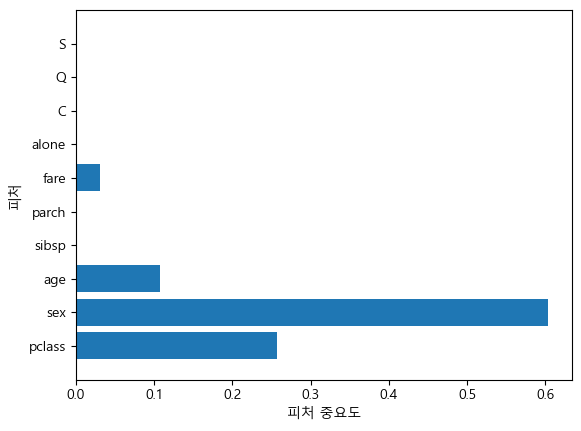

In [42]:
import numpy as np
import matplotlib.pyplot as plt

print("피처 중요도:", model.feature_importances_)

plt.rcParams["font.family"] = 'Malgun Gothic'
n_features = X_train.shape[1]
plt.barh(np.arange(n_features), model.feature_importances_, align="center")
plt.yticks(np.arange(n_features), X_train.columns)
plt.xlabel("피처 중요도")
plt.ylabel("피처")
plt.ylim(-1,n_features)

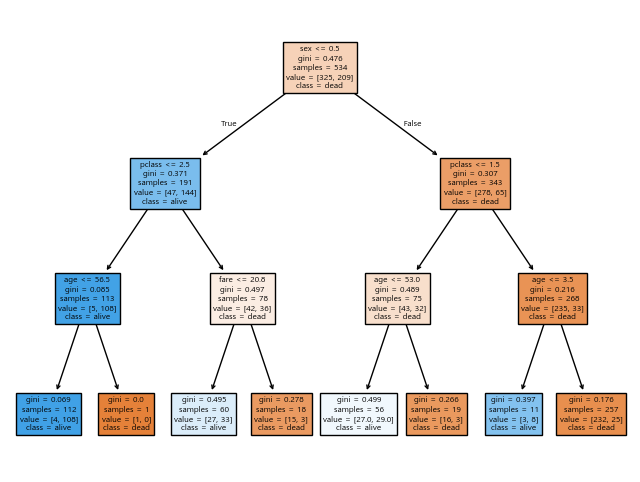

In [44]:
from sklearn.tree import plot_tree

label_val = {0: 'dead', 1:'alive'}

plt.figure(figsize=(8,6))
plot_tree(model.fit(X_train, y_train), feature_names = X_train.columns, class_names = label_val, filled = True)
plt.show()

In [46]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=3, criterion='entropy', splitter='best', min_samples_split=5, min_samples_leaf=2, max_leaf_nodes=3)
model.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [56]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold

dt_model = DecisionTreeClassifier()
cv = KFold(n_splits=5, random_state=42, shuffle=True)
parameters = {"max_depth" : [2,3,4,5,6,7,8,9,10], "criterion" :['gini','entropy'], "splitter" : ['best', 'random'],
            "min_samples_split" : [2,3,4,5,6,7,8,9], "min_samples_leaf" :[2,3,4,5,6,7,8,9], "max_leaf_nodes" : [2,3,4,5,6,7,8,9]}
model = GridSearchCV(estimator = dt_model,
                     param_grid = parameters,
                     cv = cv, verbose = 1,
                     n_jobs = 1, refit = True)
model.fit(X_train, y_train)

Fitting 5 folds for each of 18432 candidates, totalling 92160 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [2, 3, ...], 'max_leaf_nodes': [2, 3, ...], 'min_samples_leaf': [2, 3, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time

In [66]:
print("Best Estimator:\n", model.best_estimator_)
print("Best Params:\n", model.best_params_)
print("Best Score:\n", model.best_score_)

Best Estimator:
 DecisionTreeClassifier(max_depth=7, max_leaf_nodes=9, min_samples_leaf=2,
                       min_samples_split=8, splitter='random')
Best Params:
 {'criterion': 'gini', 'max_depth': 7, 'max_leaf_nodes': 9, 'min_samples_leaf': 2, 'min_samples_split': 8, 'splitter': 'random'}
Best Score:
 0.8259037206841826


In [57]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
import warnings
warnings.filterwarnings('ignore')

In [58]:
df = pd.read_csv("boston_house.csv")
df.head(2)

,AGE,B,RM,CRIM,DIS,INDUS,LSTAT,NOX,PTRATIO,RAD,ZN,TAX,CHAS,Target
0,65.2,396.9,6.575,0.00632,4.0900,2.31,4.98,0.538,15.3,1,18.0,296,0,24.0
1,78.9,396.9,6.421,0.02731,4.9671,7.07,9.14,0.469,17.8,2,0.0,242,0,21.6


In [59]:
X = df.drop('Target', axis=1)
y = df['Target']

In [60]:
# 리프노드에 있는 값들의 평균값을 반환
reg = DecisionTreeRegressor(
    criterion = 'squared_error', # MSE
    splitter = 'best',
    max_depth = 3,
    min_samples_leaf = 10,
    random_state = 100).fit(X,y)

In [61]:
reg.predict(X)[:3]

array([22.6506383 , 22.6506383 , 35.24782609])

In [62]:
for i, col in enumerate(X.columns):
    print(f"{col} 중요도 : {reg.feature_importances_[i]}")

AGE 중요도 : 0.0
B 중요도 : 0.0
RM 중요도 : 0.6777780289645088
CRIM 중요도 : 0.03439671315633408
DIS 중요도 : 0.0
INDUS 중요도 : 0.0
LSTAT 중요도 : 0.27923067295220727
NOX 중요도 : 0.0
PTRATIO 중요도 : 0.008594584926949964
RAD 중요도 : 0.0
ZN 중요도 : 0.0
TAX 중요도 : 0.0
CHAS 중요도 : 0.0


In [63]:
print(reg.get_params())

{'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 3, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 10, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 100, 'splitter': 'best'}


In [64]:
print("정확도 : ", reg.score(X,y))

정확도 :  0.7737076435842268


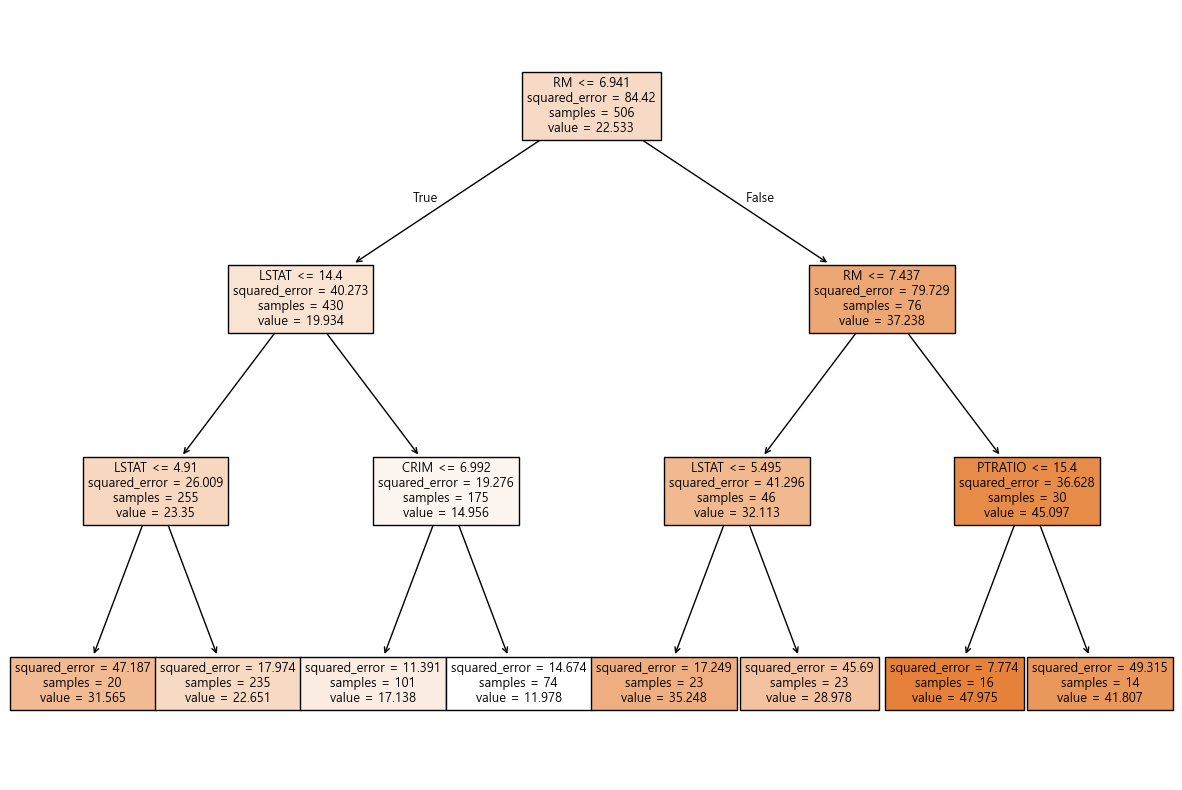

In [65]:
fig = plt.figure(figsize=(15,10))
plot_tree(reg, feature_names = X.columns, filled=True)
plt.show()

### 서울 지역 분류 실습
- district: 행정구역 (서초구, 송파구, 용산구 등, 서울의 단위 지역 분류입니다)
- dong: 구(district)보다 작은 행정구역 (대치동, 도곡동, 암사동 등, 서울의 소단위 분류입니다)
- longitude: 경도
- latitude: 위도
- label: 한강 기준으로 동,서,남,북으로 구분한 지역 명칭

In [1]:
import pandas as pd
import numpy as np

In [2]:
district_dict_list = [
            {'district': 'Gangseo-gu', 'latitude': 37.551000, 'longitude': 126.849500, 'label':'Gangseo'},
            {'district': 'Yangcheon-gu', 'latitude': 37.52424, 'longitude': 126.855396, 'label':'Gangseo'},
            {'district': 'Guro-gu', 'latitude': 37.4954, 'longitude': 126.8874, 'label':'Gangseo'},
            {'district': 'Geumcheon-gu', 'latitude': 37.4519, 'longitude': 126.9020, 'label':'Gangseo'},
            {'district': 'Mapo-gu', 'latitude': 37.560229, 'longitude': 126.908728, 'label':'Gangseo'},
            
            {'district': 'Gwanak-gu', 'latitude': 37.487517, 'longitude': 126.915065, 'label':'Gangnam'},
            {'district': 'Dongjak-gu', 'latitude': 37.5124, 'longitude': 126.9393, 'label':'Gangnam'},
            {'district': 'Seocho-gu', 'latitude': 37.4837, 'longitude': 127.0324, 'label':'Gangnam'},
            {'district': 'Gangnam-gu', 'latitude': 37.5172, 'longitude': 127.0473, 'label':'Gangnam'},
            {'district': 'Songpa-gu', 'latitude': 37.503510, 'longitude': 127.117898, 'label':'Gangnam'},
   
            {'district': 'Yongsan-gu', 'latitude': 37.532561, 'longitude': 127.008605, 'label':'Gangbuk'},
            {'district': 'Jongro-gu', 'latitude': 37.5730, 'longitude': 126.9794, 'label':'Gangbuk'},
            {'district': 'Seongbuk-gu', 'latitude': 37.603979, 'longitude': 127.056344, 'label':'Gangbuk'},
            {'district': 'Nowon-gu', 'latitude': 37.6542, 'longitude': 127.0568, 'label':'Gangbuk'},
            {'district': 'Dobong-gu', 'latitude': 37.6688, 'longitude': 127.0471, 'label':'Gangbuk'},
     
            {'district': 'Seongdong-gu', 'latitude': 37.557340, 'longitude': 127.041667, 'label':'Gangdong'},
            {'district': 'Dongdaemun-gu', 'latitude': 37.575759, 'longitude': 127.025288, 'label':'Gangdong'},
            {'district': 'Gwangjin-gu', 'latitude': 37.557562, 'longitude': 127.083467, 'label':'Gangdong'},
            {'district': 'Gangdong-gu', 'latitude': 37.554194, 'longitude': 127.151405, 'label':'Gangdong'},
            {'district': 'Jungrang-gu', 'latitude': 37.593684, 'longitude': 127.090384, 'label':'Gangdong'}
         ]

train_df = pd.DataFrame(district_dict_list)
train_df = train_df[['district', 'longitude', 'latitude', 'label']]

In [3]:
dong_dict_list = [
            {'dong': 'Gaebong-dong', 'latitude': 37.489853, 'longitude': 126.854547, 'label':'Gangseo'},
            {'dong': 'Gochuk-dong', 'latitude': 37.501394, 'longitude': 126.859245, 'label':'Gangseo'},
            {'dong': 'Hwagok-dong', 'latitude': 37.537759, 'longitude': 126.847951, 'label':'Gangseo'},
            {'dong': 'Banghwa-dong', 'latitude': 37.575817, 'longitude': 126.815719, 'label':'Gangseo'},
            {'dong': 'Sangam-dong', 'latitude': 37.577039, 'longitude': 126.891620, 'label':'Gangseo'},
            
            {'dong': 'Nonhyun-dong', 'latitude': 37.508838, 'longitude': 127.030720, 'label':'Gangnam'},
            {'dong': 'Daechi-dong', 'latitude': 37.501163, 'longitude': 127.057193, 'label':'Gangnam'},
            {'dong': 'Seocho-dong', 'latitude': 37.486401, 'longitude': 127.018281, 'label':'Gangnam'},
            {'dong': 'Bangbae-dong', 'latitude': 37.483279, 'longitude': 126.988194, 'label':'Gangnam'},
            {'dong': 'Dogok-dong', 'latitude': 37.492896, 'longitude': 127.043159, 'label':'Gangnam'},
    
            {'dong': 'Pyoungchang-dong', 'latitude': 37.612129, 'longitude': 126.975724, 'label':'Gangbuk'},
            {'dong': 'Sungbuk-dong', 'latitude': 37.597916, 'longitude': 126.998067, 'label':'Gangbuk'},
            {'dong': 'Ssangmoon-dong', 'latitude': 37.648094, 'longitude': 127.030421, 'label':'Gangbuk'},
            {'dong': 'Ui-dong', 'latitude': 37.648446, 'longitude': 127.011396, 'label':'Gangbuk'},
            {'dong': 'Samcheong-dong', 'latitude': 37.591109, 'longitude': 126.980488, 'label':'Gangbuk'},
    
            {'dong': 'Hwayang-dong', 'latitude': 37.544234, 'longitude': 127.071648, 'label':'Gangdong'},
            {'dong': 'Gui-dong', 'latitude': 37.543757, 'longitude': 127.086803, 'label':'Gangdong'},
            {'dong': 'Neung-dong', 'latitude': 37.553102, 'longitude': 127.080248, 'label':'Gangdong'},
            {'dong': 'Amsa-dong', 'latitude': 37.552370, 'longitude': 127.127124, 'label':'Gangdong'},
            {'dong': 'Chunho-dong', 'latitude': 37.547436, 'longitude': 127.137382, 'label':'Gangdong'}
         ]

test_df = pd.DataFrame(dong_dict_list)
test_df = test_df[['dong', 'longitude', 'latitude', 'label']]

In [4]:
train_df

,district,longitude,latitude,label
0,Gangseo-gu,126.849500,37.551000,Gangseo
1,Yangcheon-gu,126.855396,37.524240,Gangseo
2,Guro-gu,126.887400,37.495400,Gangseo
3,Geumcheon-gu,126.902000,37.451900,Gangseo
4,Mapo-gu,126.908728,37.560229,Gangseo
5,Gwanak-gu,126.915065,37.487517,Gangnam
6,Dongjak-gu,126.939300,37.512400,Gangnam
7,Seocho-gu,127.032400,37.483700,Gangnam
8,Gangnam-gu,127.047300,37.517200,Gangnam
9,Songpa-gu,127.117898,37.503510,Gangnam


In [5]:
train_df.label.value_counts()

label
Gangseo     5
Gangnam     5
Gangbuk     5
Gangdong    5
Name: count, dtype: int64

In [6]:
test_df.label.value_counts()

label
Gangseo     5
Gangnam     5
Gangbuk     5
Gangdong    5
Name: count, dtype: int64

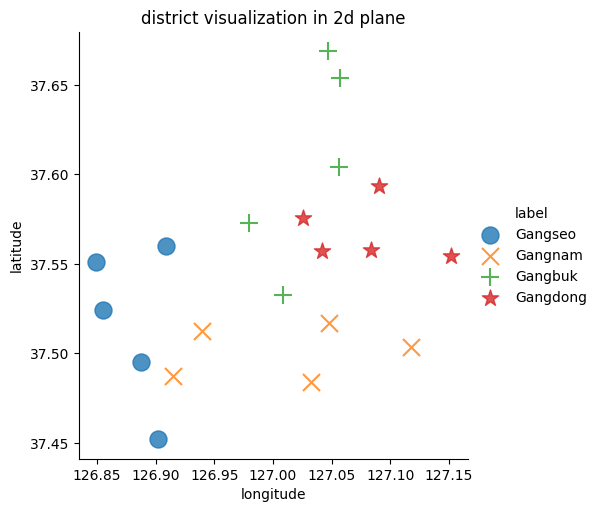

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.lmplot(x='longitude', y='latitude', data=train_df, fit_reg=False, scatter_kws={"s":150},
           markers=["o","x","+","*"], hue="label")
plt.title('district visualization in 2d plane')
plt.show()

In [8]:
train_df.drop(['district'], axis=1, inplace = True)
test_df.drop(['dong'], axis=1, inplace = True)

X_train = train_df[['longitude', 'latitude']]
y_train = train_df[['label']]

X_test = test_df[['longitude', 'latitude']]
y_test = test_df[['label']]

In [9]:
from sklearn import tree
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing

In [10]:
def display_decision_surface(clf,X, y):
    x_min = X.longitude.min() - 0.01
    x_max = X.longitude.max() + 0.01
    y_min = X.latitude.min() - 0.01
    y_max = X.latitude.max() + 0.01

    n_classes = len(le.classes_)
    plot_colors = "rywb"
    plot_step = 0.001

    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step), np.arange(y_min, y_max, plot_step))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu)

    for i, color in zip(range(n_classes), plot_colors):
        idx = np.where(y == i) 
        plt.scatter(X.loc[idx].longitude, 
                    X.loc[idx].latitude, 
                    c=color, 
                    label=le.classes_[i],
                    cmap=plt.cm.RdYlBu, edgecolor='black', s=200)

    plt.title("Decision surface of a decision tree",fontsize=16)
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize=14)
    plt.xlabel('longitude',fontsize=16)
    plt.ylabel('latitude',fontsize=16)
    plt.rcParams["figure.figsize"] = [7,5]
    plt.rcParams["font.size"] = 14
    plt.rcParams["xtick.labelsize"] = 14
    plt.rcParams["ytick.labelsize"] = 14
    plt.show()

C:\Project\Python_Source\AI01\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Project\Python_Source\AI01\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_14188\757516415.py:18: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X.loc[idx].longitude,


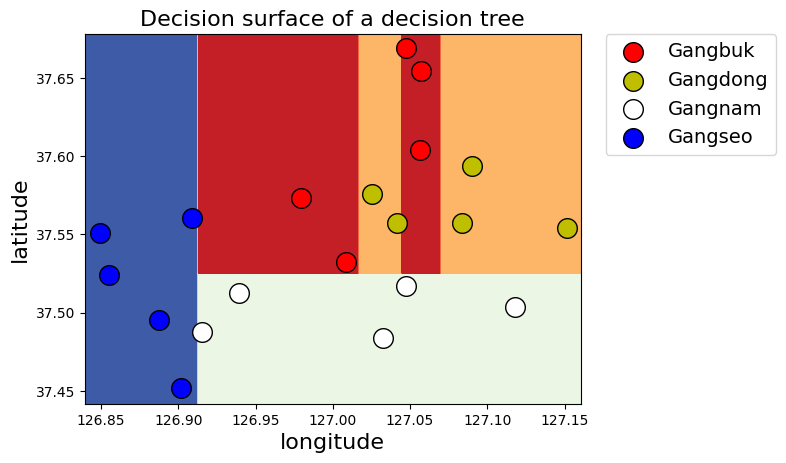

In [11]:
le = preprocessing.LabelEncoder()
y_encoded = le.fit_transform(y_train)

clf = tree.DecisionTreeClassifier(random_state=35).fit(X_train, y_encoded)
display_decision_surface(clf,X_train, y_encoded)

#### 가지치기

C:\Project\Python_Source\AI01\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_14188\757516415.py:18: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X.loc[idx].longitude,


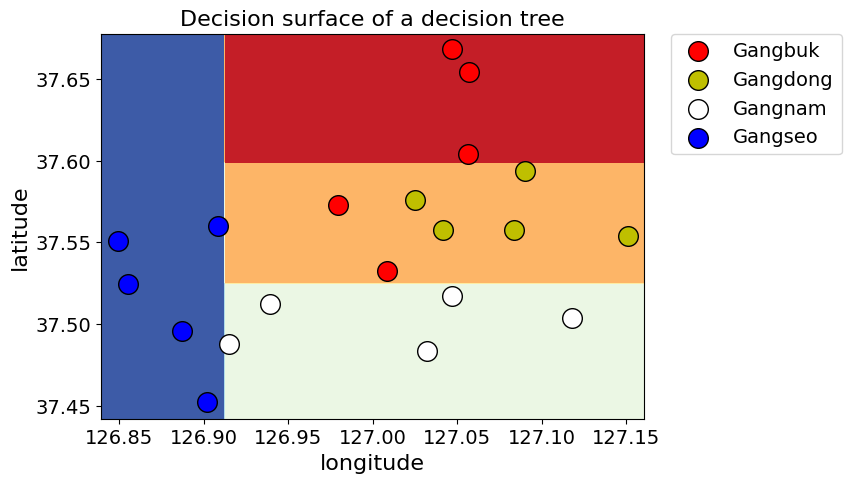

In [13]:
clf = tree.DecisionTreeClassifier(max_depth=3, 
                                  min_samples_split=3,
                                  min_samples_leaf=3, 
                                  random_state=5).fit(X_train, y_encoded.ravel())
display_decision_surface(clf,X_train, y_encoded)